In [2]:
# Importar las librerias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## Analisis Exploratorio de los datos 

In [4]:
ventas_df = pd.read_excel("Layout ventas.xlsx", sheet_name='Ventas')

In [5]:
# Renombrar las columas de excel para hacer mas claro el procesamiento
ventas_df.columns = ['ID','Fecha','Año','Operacion','TipoInmueble','Monto']


In [6]:
#Crear una copia del data frame
df = ventas_df

In [7]:
df.head(5)

,ID,Fecha,Año,Operacion,TipoInmueble,Monto
0,2,2021-06-01,2021,Venta,Casa,70500
1,3,2021-07-01,2021,Venta,Casa,25500
2,4,2021-08-01,2021,Venta,Casa,62500
3,5,2021-09-01,2021,Venta,Casa,144800
4,6,2021-10-01,2021,Venta,Departamento,24600


In [8]:
df.shape

(66, 6)

In [9]:
# Ver si existen valores faltantes
df.isnull().sum()

ID              0
Fecha           0
Año             0
Operacion       0
TipoInmueble    0
Monto           0
dtype: int64

In [10]:
# Obtner la media de ventas
df["Monto"].mean()

24010.484848484848

In [11]:
df.describe()

,ID,Fecha,Año,Monto
count,66.000000,66,66.000000,66.000000
mean,28.303030,2022-11-25 14:54:32.727272704,2022.015152,24010.484848
min,2.000000,2021-06-01 00:00:00,2021.000000,4000.000000
25%,20.250000,2022-06-11 18:00:00,2022.000000,10000.000000
50%,29.500000,2022-10-29 00:00:00,2022.000000,13828.000000
75%,38.000000,2023-08-06 18:00:00,2022.000000,35762.500000
max,50.000000,2023-12-12 00:00:00,2023.000000,144800.000000
std,12.647857,NaN,0.480142,22334.377530


In [12]:
# Importar las librerias
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

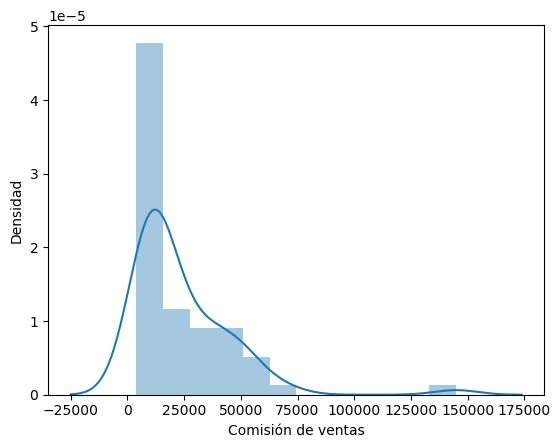

In [13]:
# Obtener grafica de comiciones
sns.distplot(df["Monto"])
plt.xlabel("Comisión de ventas")
plt.ylabel("Densidad")
#plt.show()
plt.savefig("Grafica_de_comisiones.jpg")

In [14]:
# Obtener la mediana
mediana = np.median(df["Monto"])
mediana

13828.0

In [15]:
# Obtner la moda 
from statistics import mode
moda = mode(df["Monto"])
moda

10000

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ID            66 non-null     int64         
 1   Fecha         66 non-null     datetime64[ns]
 2   Año           66 non-null     int64         
 3   Operacion     66 non-null     object        
 4   TipoInmueble  66 non-null     object        
 5   Monto         66 non-null     int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 3.2+ KB


## Ver galeria de graficos Seaborn
https://seaborn.pydata.org/examples/index.html

In [18]:
df["monto"] = pd.to_numeric(df["Monto"], errors="coerce")


In [19]:
tipo_inmueble= df.groupby("TipoInmueble")["Monto"].mean()
tipo_inmueble

TipoInmueble
Casa                 39470.538462
Departamento         20581.372549
Tramite Infonavit    10962.500000
Name: Monto, dtype: float64

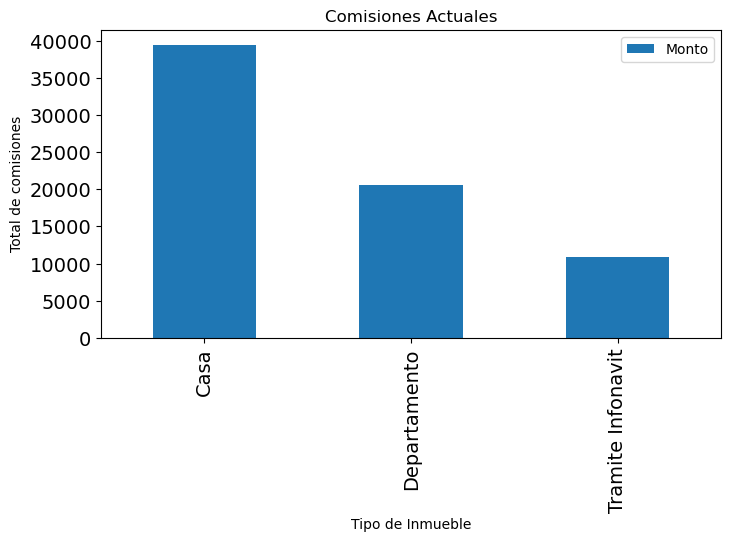

In [20]:
tipo_inmueble.plot(
    kind="bar",
    fontsize=14,
    figsize=(8,4),
    legend= True,
    title="Comisiones Actuales",
    xlabel="Tipo de Inmueble",
    ylabel="Total de comisiones"
)
#plt.show()
plt.savefig("Grafico_Comisiones_Tipo_Inmueble.jpg")

In [21]:
# Agrupacion por meses y calcular el total de comisiones
df["Mes"] = df["Fecha"].dt.to_period('M')


In [22]:
df.head()

,ID,Fecha,Año,Operacion,TipoInmueble,Monto,monto,Mes
0,2,2021-06-01,2021,Venta,Casa,70500,70500,2021-06
1,3,2021-07-01,2021,Venta,Casa,25500,25500,2021-07
2,4,2021-08-01,2021,Venta,Casa,62500,62500,2021-08
3,5,2021-09-01,2021,Venta,Casa,144800,144800,2021-09
4,6,2021-10-01,2021,Venta,Departamento,24600,24600,2021-10


In [23]:
# Agrupar
df_month = df.groupby('Mes').sum(numeric_only=True)


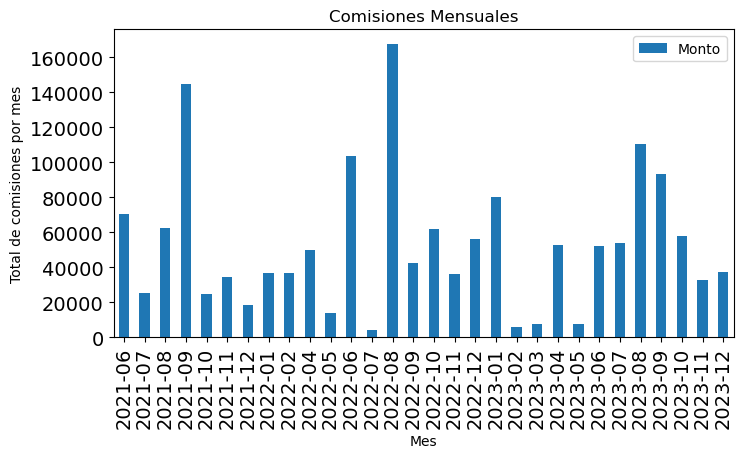

In [24]:
df_month['Monto'].plot(
    kind='bar',
    fontsize=14,
    figsize=(8,4),
    legend=True,
    title='Comisiones Mensuales',
    xlabel='Mes',
    ylabel='Total de comisiones por mes'
)
plt.show()

In [25]:
# Crear una grafica de Pastel para agrupar las ventas por año
df_year = df.groupby(pd.PeriodIndex(df["Fecha"], freq='Y')).sum(numeric_only=True)
print(df_year.head(3))

        ID    Año   Monto   monto
Fecha                            
2021    35  14147  380700  380700
2022   846  64704  610288  610288
2023   987  54602  593704  593704


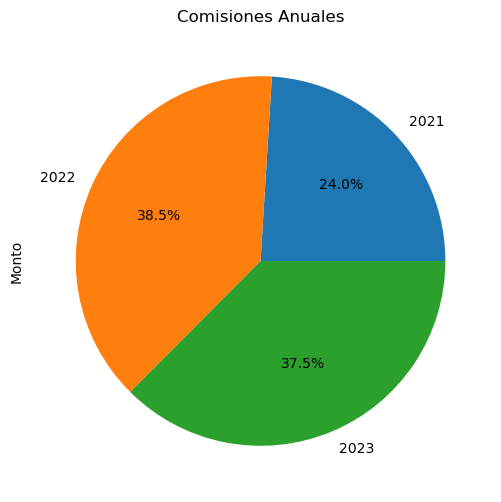

In [26]:
df_year["Monto"].plot(
    kind='pie',
    figsize=(8,6),
    autopct="%0.1f%%",
    labels=df_year.index,
    title="Comisiones Anuales"
)
plt.show()

## Preparacion de los datos

In [28]:
#Importar las librerias
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [29]:
# Convertir la columna 'fecha' a tipo de dato datetime
ventas_df["Fecha"] = pd.to_datetime(ventas_df["Fecha"], errors="coerce")

In [30]:
ventas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ID            66 non-null     int64         
 1   Fecha         66 non-null     datetime64[ns]
 2   Año           66 non-null     int64         
 3   Operacion     66 non-null     object        
 4   TipoInmueble  66 non-null     object        
 5   Monto         66 non-null     int64         
 6   monto         66 non-null     int64         
 7   Mes           66 non-null     period[M]     
dtypes: datetime64[ns](1), int64(4), object(2), period[M](1)
memory usage: 4.3+ KB


In [31]:
# Aplicar la codificacion one hot a las columnas 'Operacion' y 'TipoInmuble'
ventas_df_new_encoded = pd.get_dummies(ventas_df, columns=["Operacion","TipoInmueble"])

In [32]:
ventas_df_new_encoded

,ID,Fecha,Año,Monto,monto,Mes,Operacion_Renta,Operacion_Tramite,Operacion_Venta,TipoInmueble_Casa,TipoInmueble_Departamento,TipoInmueble_Tramite Infonavit
0,2,2021-06-01,2021,70500,70500,2021-06,False,False,True,True,False,False
1,3,2021-07-01,2021,25500,25500,2021-07,False,False,True,True,False,False
2,4,2021-08-01,2021,62500,62500,2021-08,False,False,True,True,False,False
3,5,2021-09-01,2021,144800,144800,2021-09,False,False,True,True,False,False
4,6,2021-10-01,2021,24600,24600,2021-10,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
61,38,2023-11-04,2022,10883,10883,2023-11,True,False,False,False,True,False
62,39,2023-11-25,2022,10883,10883,2023-11,False,False,True,False,True,False
63,40,2023-11-30,2022,10883,10883,2023-11,False,False,True,False,True,False
64,41,2023-12-10,2022,30000,30000,2023-12,False,False,True,True,False,False


In [33]:
# Definir las variables predictoras (x)
x_new_segmented = ventas_df_new_encoded[['Año','TipoInmueble_Departamento', 'Operacion_Tramite', 'Operacion_Venta']]


In [34]:
# Definir la variable objetivo(y)
y_new_segmented = ventas_df_new_encoded['Monto']

In [35]:
# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(x_new_segmented, y_new_segmented, test_size=0.2, random_state=42)

## procesamiento de Datos

In [37]:
# Crear el modelo de Random Forest
rf_model_segmented = RandomForestRegressor(random_state=42, n_estimators=100)

In [38]:
# Entrenar la palabra fit 
rf_model_segmented.fit(X_train,Y_train)

RandomForestRegressor(random_state=42)

In [39]:
X_test

,Año,TipoInmueble_Departamento,Operacion_Tramite,Operacion_Venta
54,2022,True,False,True
62,2022,True,False,True
0,2021,False,False,True
45,2023,True,False,True
5,2021,True,False,True
63,2022,True,False,True
16,2022,True,False,True
12,2022,True,False,True
65,2022,False,True,False
30,2022,True,False,False


In [40]:
#Generando la prediccion
y_rf_pred_segmented = rf_model_segmented.predict(X_test)


In [41]:
y_rf_pred_segmented

array([22036.79169   , 22036.79169   , 77488.18368867, 46702.63492063,
       28626.34079654, 22036.79169   , 22036.79169   , 22036.79169   ,
       14486.78976601, 11966.79711486, 22036.79169   , 27170.96227672,
       11788.53874811, 22036.79169   ])

In [85]:
#Calcular el RMSE(Error Cuadratico Medio) para el modelo de Random Forest
rf_rmse = np.sqrt(mean_squared_error(Y_test,y_rf_pred_segmented))

In [87]:
#Mostrar RMSE
print("RMSE del modelo",rf_rmse)

RMSE del modelo 11879.76118130803


## Un RMSE mas bajo indica un mejor ajuste del modelo, es decir las predicciones estan mas cerca de los valores reales

## Un  RMSE más alto indica un peor ajuste de los datos, con predicciones alejadas de los valores reales

Es decir en nuestros caso, el 10 % del rango de ventas (144,800-4000 = 140,800) seria 14,080 
Esto representa el 10% del rango de los datos
Entonces un RMSE cercano o por debajo de este valor puede ser aceptable para modelo

In [42]:
# Guardar todas las predicciones en comiciones en un archivo CSV
predicciones_df= pd.DataFrame({
    "Comisiones Reales": Y_test.values,
    "Predicciones": y_rf_pred_segmented
})

In [43]:
#Guardar el archivo en csv
cvs_output_path="predicciones_ventas.csv"
predicciones_df.to_csv(cvs_output_path, index=False)

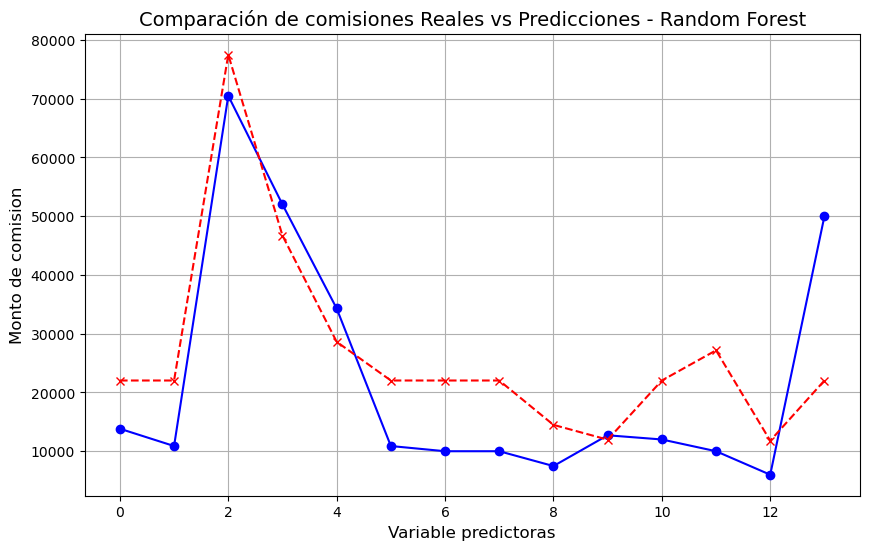

In [45]:
import matplotlib.pyplot as plt
#Crear un grafico de lineas comparando las comisiones reales contra las predicciones
plt.figure(figsize=(10,6))
plt.plot(Y_test.values, label="Comisiones reales", marker="o", linestyle='-', color="blue")
plt.plot(y_rf_pred_segmented, label="Comisiones Predichas", marker="x", linestyle='--', color="red")
plt.title("Comparación de comisiones Reales vs Predicciones - Random Forest", fontsize=14)
plt.xlabel("Variable predictoras", fontsize=12)
plt.ylabel("Monto de comision", fontsize=12)
plt.grid(True)
plt.show()

In [47]:
data_2024 = {
    "Año":[2024]*10,
    "TipoInmueble_Departamento":[1,0,1,0,1,0,1,0,1,0], # Alternamos entre Departamento y otro tipo de inmueble
    "Operacion_Tramite":[0,1,0,0,1,0,1,0,0,1], # Alternamos entre Tramite y otras operaciones
    "Operacion_Venta":[1,0,1,1,0,1,0,1,1,0] #Alternammos entre Ventas y otras operaciones
}

In [53]:
df_2024 = pd.DataFrame(data_2024)

In [57]:
#Convertir el diccionario en un DataFrame
df_2024.head()

,Año,TipoInmueble_Departamento,Operacion_Tramite,Operacion_Venta
0,2024,1,0,1
1,2024,0,1,0
2,2024,1,0,1
3,2024,0,0,1
4,2024,1,1,0


In [61]:
#Usar el modelo entrenado para predecir las comisiones 2024
proyeccion_comisiones_2024=rf_model_segmented.predict(df_2024)


In [63]:
#Mostrar la proyeccion de comisiones
proyeccion_comisiones_2024

array([46702.63492063, 12234.42717949, 46702.63492063, 45478.54977778,
       11035.65227753, 45478.54977778, 11035.65227753, 45478.54977778,
       46702.63492063, 12234.42717949])

In [65]:
# Guardar las proyecciones de comisiones para el año 2024
predicciones_df= pd.DataFrame({
    "Año": [2024] * len(proyeccion_comisiones_2024),
    "Predicciones_Comisiones": proyeccion_comisiones_2024
})

In [67]:
predicciones_df

,Año,Predicciones_Comisiones
0,2024,46702.634921
1,2024,12234.427179
2,2024,46702.634921
3,2024,45478.549778
4,2024,11035.652278
5,2024,45478.549778
6,2024,11035.652278
7,2024,45478.549778
8,2024,46702.634921
9,2024,12234.427179


In [71]:
predicciones_df.to_csv("proyeccion_comisiones_2024.csv",index=False)

## Resultado de procesamiento

In [79]:
import matplotlib.pyplot as plt
#Agrupar los datos historicos (201-2023) 
comisiones_por_año = ventas_df.groupby("Año")["Monto"].sum()

In [81]:
# Añadir las predicciones para 2024 al DataFrame
 #Accede a una fila del DataFrame con el indice 2024
comisiones_por_año.loc[2024] = predicciones_df["Predicciones_Comisiones"].sum()


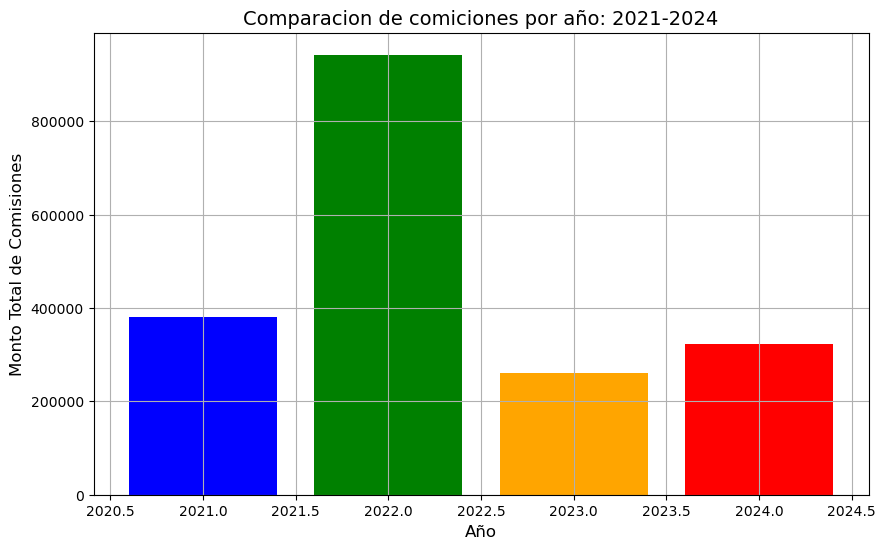

In [83]:
# Crear el grafico comparando los años 2021,2022,2023, y las proyeccicones de 2024
plt.figure(figsize=(10,6))
plt.bar(comisiones_por_año.index,comisiones_por_año.values,color=["blue","green","orange","red"])
plt.title("Comparacion de comiciones por año: 2021-2024", fontsize=14)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Monto Total de Comisiones", fontsize=12)
plt.grid(True)
plt.show()